From Sam: I moved the Gapminder code out of lec27 and into this supplemental notebook.


In [ ]:
import numpy as np
import babypandas as bpd
import pandas as pd

## Demo: Gapminder 🌎

### `plotly`

- All of the visualizations (scatter plots, histograms, etc.) in this course were created using a library called `matplotlib`.
    - This library was called under-the-hood everytime we wrote `df.plot`.
- `plotly` is a different visualization library that allows us to create **interactive** visualizations.
- You may learn about it in a future course, but we'll briefly show you some cool visualizations you can make with it.

In [2]:
import plotly.express as px

### Gapminder dataset

> Gapminder Foundation is a non-profit venture registered in Stockholm, Sweden, that promotes sustainable global development and achievement of the United Nations Millennium Development Goals by increased use and understanding of statistics and other information about social, economic and environmental development at local, national and global levels. - [Gapminder Wikipedia](https://en.wikipedia.org/wiki/Gapminder_Foundation)

In [3]:
gapminder = px.data.gapminder()
gapminder

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


The dataset contains information for each country for several different years.

In [4]:
gapminder.get('year').unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

Let's start by just looking at 2007 data (the most recent year in the dataset).

In [5]:
gapminder_2007 = gapminder[gapminder.get('year') == 2007]
gapminder_2007

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32
...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894


### Scatter plot

We can plot life expectancy vs. GDP per capita. If you hover over a point, you will see the name of the country.

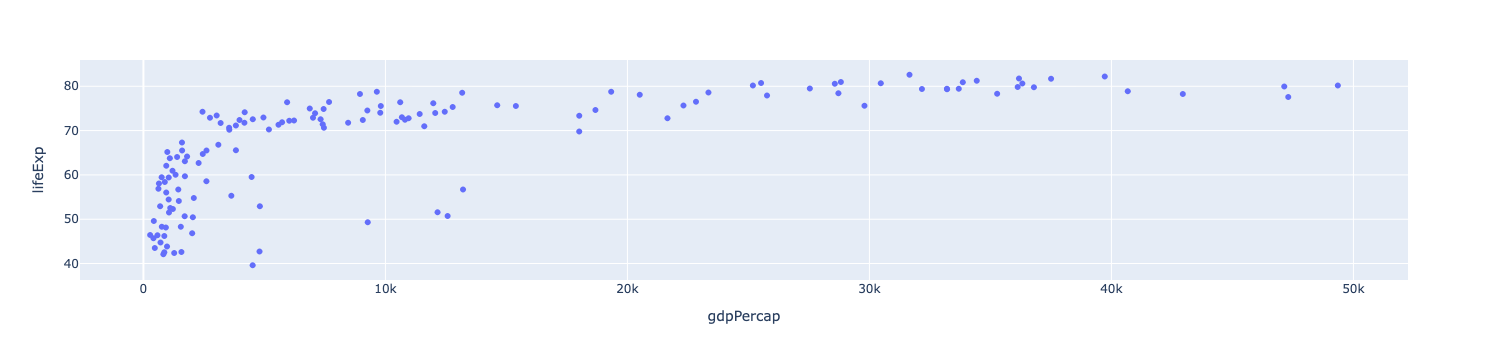

In [6]:
px.scatter(gapminder_2007, x='gdpPercap', y='lifeExp', hover_name='country')

In future courses, you'll learn about transformations. Here, we'll apply a log transformation to the x-axis to make the plot look a little more linear.

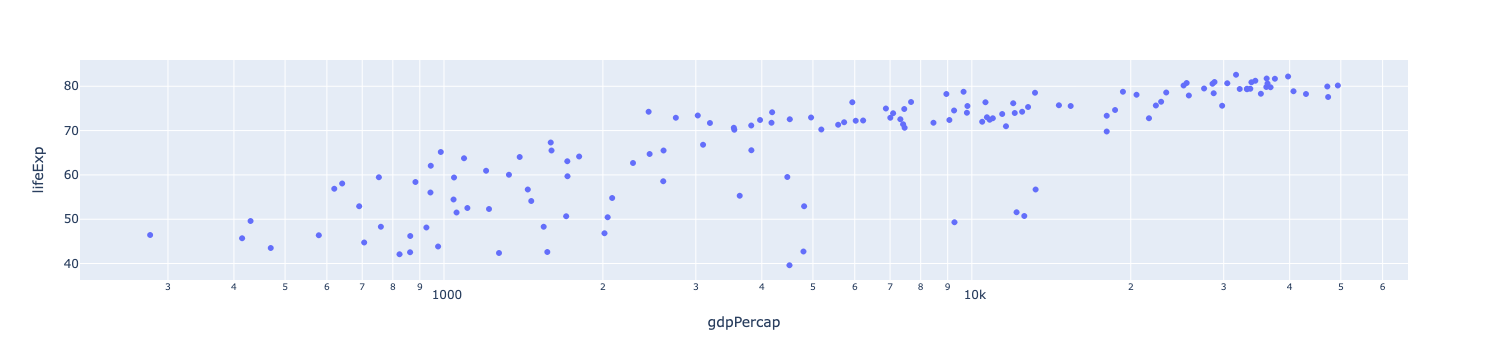

In [7]:
px.scatter(gapminder_2007, x='gdpPercap', y='lifeExp', log_x=True, hover_name='country')

### Choropleth

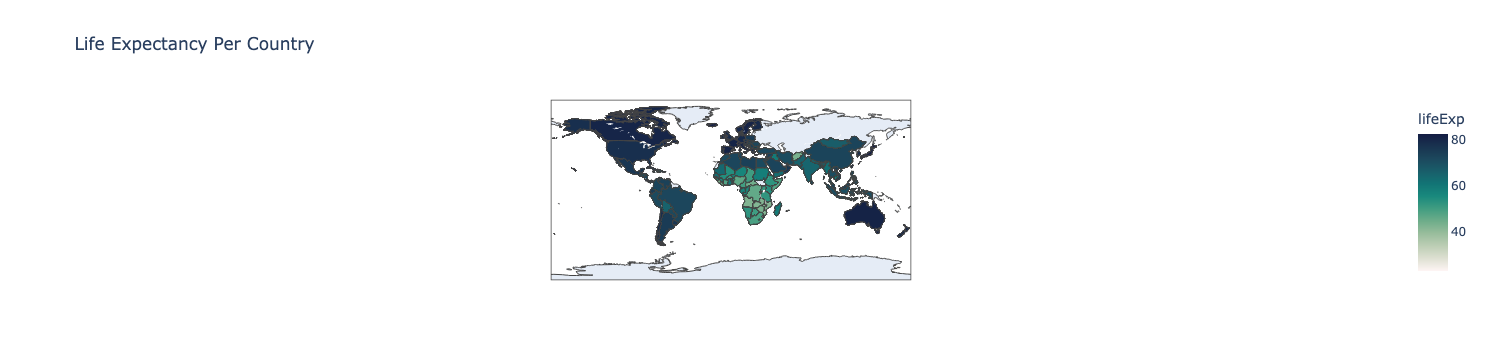

In [10]:
px.choropleth(gapminder,
              locations = 'iso_alpha',
              color = 'lifeExp',
              hover_name = 'country',
              hover_data = {'iso_alpha': False},
              title = 'Life Expectancy Per Country',
              color_continuous_scale = px.colors.sequential.tempo
)